# Partie 4 : Visualisation en temps reel

Ce notebook affiche les donnees InfluxDB en direct avec une fenetre glissante.

Champs disponibles : temp, hum, co2, power, occupied.

Prerequis : lancer d'abord notebooks/0_db-filler.ipynb pour generer des donnees en continu.

In [3]:
from influxdb_client import InfluxDBClient
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

# Config InfluxDB (identique au script de generation)
URL = "http://influxdb2:8086"
TOKEN = "MyInitialAdminToken0=="
ORG = "docs"
BUCKET = "home"
MEASUREMENT = "home"

client = InfluxDBClient(url=URL, token=TOKEN, org=ORG)
query_api = client.query_api()


def fetch_last_window(field: str = "temp", window: str = "15m") -> pd.DataFrame:
    flux_query = f'''
from(bucket: \"{BUCKET}\")
  |> range(start: -{window})
  |> filter(fn: (r) => r._measurement == \"{MEASUREMENT}\")
  |> filter(fn: (r) => r._field == \"{field}\")
  |> keep(columns: [\"_time\", \"_value\", \"room\"])
  |> sort(columns: [\"_time\"])
'''

    tables = query_api.query(flux_query)

    rows = []
    for table in tables:
        for record in table.records:
            rows.append(
                {
                    "time": record.get_time(),
                    "room": record.values.get("room", "unknown"),
                    "value": record.get_value(),
                }
            )

    if not rows:
        return pd.DataFrame(columns=["time", "room", "value"])

    df = pd.DataFrame(rows)
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df


def live_plot(field: str = "temp", window: str = "15m", refresh_seconds: int = 2) -> None:
    try:
        while True:
            df = fetch_last_window(field=field, window=window)

            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(11, 4))

            if df.empty:
                ax.text(0.5, 0.5, "Aucune donnee disponible", ha="center", va="center")
                ax.set_axis_off()
            else:
                for room, group in df.groupby("room"):
                    ax.plot(group["time"], group["value"], label=room)

                ax.legend(loc="upper left", ncol=3)
                ax.set_title(f"{field} - fenetre glissante {window}")
                ax.set_xlabel("Temps")
                ax.set_ylabel(field)
                ax.grid(alpha=0.25)
                fig.autofmt_xdate()

            display(fig)
            plt.close(fig)
            time.sleep(refresh_seconds)

    except KeyboardInterrupt:
        print("Visualisation arretee.")


def close_influx_client() -> None:
    client.close()

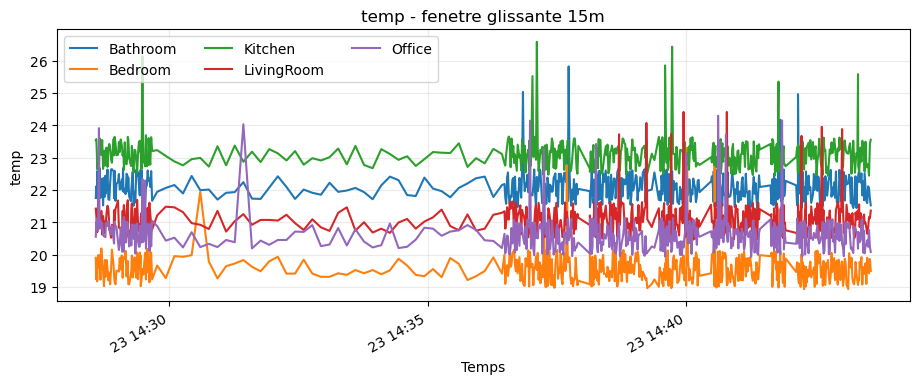

Visualisation arretee.


In [4]:
# Lancement de la visualisation temps reel
# Stoppez la cellule pour arreter l'affichage.
live_plot(field="temp", window="15m", refresh_seconds=2)

In [ ]:
#fermer proprement le client InfluxDB
close_influx_client()